In [1]:
from senseai import SenseAI
import cv2
import json
import numpy as np
import os
import matplotlib.pyplot as plt
### test using webcam
from fibsem.SenseAI_SG import SenseAI_Config



In [3]:
hydra_workspace = SenseAI_Config(r"C:\Users\Administrator\Documents\SenseAI\Workspaces\hydra_workspace.json")

In [6]:
name = hydra_workspace.detector_config["Name"]
print(name)

Analogue Detector at Input 0


In [2]:
SenseAI_version_path = r"C:\Program Files\SenseAI\SenseAI 2026.1.1"

current_dir = os.getcwd()

s = SenseAI(os.path.join(SenseAI_version_path,"SenseAI.dll"))

sg = s.hw.add_scan_generator("WCScanGen", "QDMock", {
    "ScanSize": [
        640,
        480
    ],
    "DwellTime": 0.010,
    "Pattern": "Raster",
    "Sampling": 1.0,
    "ResetBuffer": True,
    "Name": "WCScanGen"
})


s.hw.add_detector("WCDetector", "ScanGenerator", sg["Name"], {
    "Input": 0,
    "QDType": "qd_analogue",
    "Name":"WCDetector"
})



{'Channels': 1,
 'Delay': 30,
 'FlybackPixels': 0,
 'ForceSupportVD': False,
 'FrameSize': [0, 0],
 'Generator': 'WCScanGen',
 'Input': 0,
 'Name': 'WCDetector',
 'QDType': 'qd_analogue',
 'ScanSize': [640, 480],
 'SupportsVirtualDetectors': False,
 'Type': 'ScanGenerator'}

In [3]:

s.hw.init_scan_generator("WCScanGen")



'Initialised'

In [4]:
s.hw.update_scan_generator("WCScanGen",
                           {
                               "Pattern":"Linehop",\
                               "Sampling":0.25,
                               "ResetBuffer":True
                           })

{'AccelerationVoltage': 0.0,
 'BeamParkPosition': '0, 0',
 'ConvergenceSemiAngle': 0.0,
 'DwellTime': 0.01,
 'Firmware': '',
 'FlybackPixels': 0,
 'FlybackTime': 0.001,
 'FrameAverage': 1,
 'FrameCounter': 0,
 'FrameNumber': 0,
 'Generator': 1,
 'Hardware': True,
 'ImageMode': 0,
 'Initialised': True,
 'Label': '',
 'LineAverage': 1,
 'Name': 'WCScanGen',
 'Pattern': 'Linehop',
 'Paused': False,
 'ResetBuffer': True,
 'RotationAngle': 0.0,
 'Sampling': 0.25,
 'ScanSize': [640, 480],
 'ScanSizeHasFlybackAdjustment': False,
 'Seed': 0,
 'Type': 'QDMock'}

In [2]:
## with microscope
SenseAI_version_path = r"C:\Program Files\SenseAI\SenseAI 2026.1.1"

s = SenseAI(os.path.join(SenseAI_version_path,"SenseAI.dll"))

workspace_hydra_config = SenseAI_Config(r"C:\Users\Administrator\Documents\SenseAI\Workspaces\hydra_workspace.json")

sc_config = workspace_hydra_config.scanGen_config
d_config = workspace_hydra_config.detector_config

# sc_config["PauseAfterEachFrame"] = True



In [3]:
print(sc_config)

{'$type': 'SenseAI.Base.Sources.QDScanGenerator, SenseAI.Base', 'FlybackTime': 0.0, 'RotationAngle': 0.0, 'ImageMode': 0, 'LineAverage': 1, 'Generator': 1, 'Hardware': True, 'Firmware': '0.0.0', 'BeamParkPosition': '0, 0', 'FrameNumber': 0, 'HandBackControlOnPause': False, 'ScanControlLine': 0, 'ScanControlLineValue': 0, 'Type': 'QD', 'Paused': False, 'Running': True, 'Initialised': False, 'SupportsMultipleDetectors': True, 'CaptureSettings': {'$type': 'SenseAI.Base.Sources.QDScanGenerator, SenseAI.Base', 'FlybackTime': 0.001, 'RotationAngle': 0.0, 'ImageMode': 0, 'LineAverage': 1, 'Generator': 1, 'Hardware': False, 'Firmware': '', 'BeamParkPosition': '', 'FrameNumber': 0, 'HandBackControlOnPause': False, 'ScanControlLine': 0, 'ScanControlLineValue': 0, 'Type': 'QD', 'Paused': False, 'Running': True, 'Initialised': False, 'SupportsMultipleDetectors': True, 'CaptureSettings': None, 'ScanSizeHasFlybackAdjustment': False, 'ScanSize': [512, 512], 'DwellTime': 0.01, 'Pattern': 'Raster', 'Sa

In [4]:
sc = s.hw.add_scan_generator("Quantum Detectors","QD",sc_config)

In [5]:
d = s.hw.add_detector("Quantum Detectors","ScanGenerator",sc["Name"],d_config)

In [ ]:
# init 
current_dir = os.getcwd()
os.chdir(SenseAI_version_path)

s.hw.init_scan_generator("Quantum Detectors")

os.chdir(current_dir)

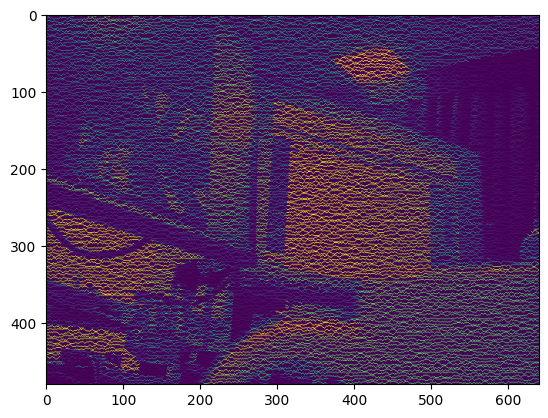

In [11]:
output3 = s.hw.get_detector_image("WCDetector")

img1 = output3[0]
mask1 = output3[1]

plt.imshow(img1)
plt.show()

In [5]:
def take_image_and_show():    

    name = "WCScanGen"

    print("Waiting")
    s.hw.wait_for_scan_gen_frame(name)
    print("setting state")
    s.hw.set_scan_generator_state(name,paused=False)
    print("waiting for frame")
    s.hw.wait_for_scan_gen_frame(name)
    print("Getting detector image")
    output = s.hw.get_detector_image("WCDetector")
    print("Pause scanning")
    s.hw.set_scan_generator_state(name,paused=True)

    plt.imshow(output[0])
    plt.show()

    return output




In [6]:
s.hw.update_scan_generator("WCScanGen",
                           {
                               "Pattern":"Linehop",
                               "Sampling":0.5,
                               "ResetBuffer":True,
                               "ScanSize": [640, 480]
                           })

{'AccelerationVoltage': 0.0,
 'BeamParkPosition': '0, 0',
 'ConvergenceSemiAngle': 0.0,
 'DwellTime': 0.01,
 'Firmware': '',
 'FlybackPixels': 0,
 'FlybackTime': 0.001,
 'FrameAverage': 1,
 'FrameCounter': 6,
 'FrameNumber': 0,
 'Generator': 1,
 'Hardware': True,
 'ImageMode': 0,
 'Initialised': True,
 'Label': '',
 'LineAverage': 1,
 'Name': 'WCScanGen',
 'Pattern': 'Linehop',
 'Paused': False,
 'ResetBuffer': True,
 'RotationAngle': 0.0,
 'Sampling': 0.5,
 'ScanSize': [640, 480],
 'ScanSizeHasFlybackAdjustment': False,
 'Seed': 0,
 'Type': 'QDMock'}

Waiting
setting state
waiting for frame
Getting detector image
Pause scanning


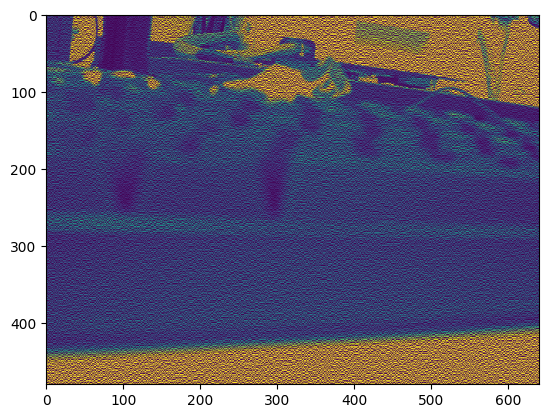

In [8]:
output =take_image_and_show()

In [32]:
print(s)

In [36]:
s.add_image("img0",output[0],output[1])

{'Axes': ['Height', 'Width', 'Channels', 'Frames'],
 'Label': '',
 'Layers': [{'IsMask': False, 'Name': 'Input', 'Shape': [480, 640, 1, 1]},
  {'IsMask': True, 'Name': 'Mask', 'Shape': [480, 640, 1, 1]},
  {'IsMask': False, 'Name': 'Reconstruction', 'Shape': [480, 640, 1, 1]},
  {'IsMask': False, 'Name': 'Reference', 'Shape': [480, 640, 1, 1]}],
 'Name': 'img0',
 'Origin': '',
 'OriginalSize': [480, 640, 1, 1],
 'Path': '',
 'Size': [480, 640, 1, 1],
 'Type': 0,
 'Units': ['px', 'px', '', ''],
 'Views': [{'Dimensions': [480, 640, 1, 1],
   'Name': 'Default',
   'View': [[-1, -1], [-1, -1], [-1, -1], [-1, -1]]}]}

In [37]:
from senseai import quick_recon, quick_recon_single
import time

In [39]:
dict_name, train, recon = quick_recon(s, image="img0", patch_shape=[5, 5, 1, 1], dict_size=36, dict_kwargs={"OnesElement": True})

for i in range(60):
    recon = s.get_image_buffer("img0", "Reconstruction")
    time.sleep(0.5)

plt.imshow(recon)
plt.show()


RuntimeError: Call failed: Failed to add source with error 'This source already exists'.

In [ ]:
img_to_use = "img0"


dict_name, train, recon = quick_recon(s, image=img_to_use, patch_shape=[10, 10, 1, 1], dict_size=36, dict_kwargs={"OnesElement": True})

try:
    while True:
        image = s.get_image_buffer(img_to_use, "Input")
        reference_data = s.get_image_array(img_to_use, "Reference")
        recon = s.get_image_buffer(img_to_use, "Reconstruction")
        dictionary = s.get_gallery_buffer(dict_name, "Default", 6.0)

        cv2.imshow("Image", image)
        cv2.imshow("Reference", reference_data)
        cv2.imshow("Reconstruction", recon)
        cv2.waitKey(1000)
except KeyboardInterrupt:
    pass

In [ ]:
# for _ in range(200):
#     buf, mask = s.hw.get_detector_image("Test", "Buffer")
#     cv2.normalize(buf, buf, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
#     buf = buf.astype(np.uint8)
#     cv2.imshow("Webcam", buf)
#     cv2.waitKey(100)
# cv2.destroyAllWindows()